# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()


Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [2]:
# TODO 1: choropleth of total_gdp
fig1 = px.choropleth(gap_latest, locations="iso_alpha", color="total_gdp",
                      hover_name="country", color_continuous_scale="Reds",
                      title="Total GDP (a count) -- dominated by population size")
fig1.show()

# TODO 2: choropleth of gdpPercap
fig2 = px.choropleth(gap_latest, locations="iso_alpha", color="gdpPercap",
                      hover_name="country", color_continuous_scale="Viridis",
                      title="GDP per capita (a rate) -- reveals actual prosperity")
fig2.show()

# TODO 3: top 5 countries by each -- print both lists
top_total = gap_latest.nlargest(5, "total_gdp")[["country", "total_gdp", "gdpPercap"]]
top_rate = gap_latest.nlargest(5, "gdpPercap")[["country", "total_gdp", "gdpPercap"]]
print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)


Top 5 by total GDP:
            country     total_gdp     gdpPercap
134  United States  1.293446e+13  42951.653090
24           China  6.539501e+12   4959.114854
66           Japan  4.035135e+12  31656.068060
58           India  2.722925e+12   2452.210407
47         Germany  2.650871e+12  32170.374420

Top 5 by GDP per capita:
            country     total_gdp    gdpPercap
95          Norway  2.284214e+11  49357.19017
71          Kuwait  1.185305e+11  47306.98978
113      Singapore  2.146433e+11  47143.17964
134  United States  1.293446e+13  42951.65309
62         Ireland  1.671412e+11  40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_ The United States is the only country appearing in both top-5 lists.
Everything else differs: China, Japan, India, and Germany top the total-GDP list (driven
by huge populations or economies) but don't appear in the per-capita top 5 at all, while
Norway, Kuwait, Singapore, and Ireland top the per-capita list but don't appear in the
total-GDP top 5. I'd show the director the GDP-per-capita map. Total GDP is exactly the
"count" trap from the brief -- it's dominated by population size (China and India rank
high mostly because they're huge, not because individual citizens are prosperous).
GDP per capita is the "rate" that actually answers the prosperity question the director
cares about, without a large, populous country automatically looking more important.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

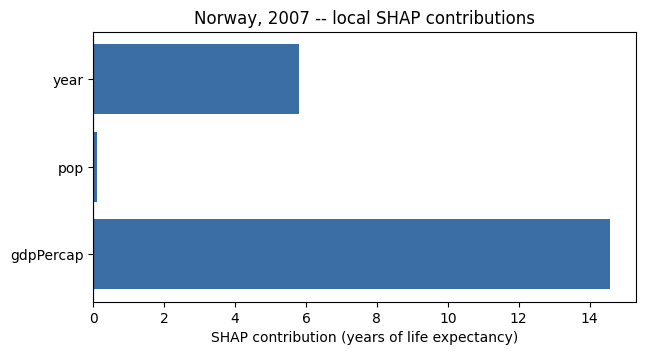

In [3]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model
rf = RandomForestRegressor(n_estimators=200, random_state=0)
rf.fit(X_model, y_model)

# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3: find Norway's row, plot its SHAP contributions
row_idx = gapminder[(gapminder.country == "Norway") & (gapminder.year == 2007)].index[0]
vals = shap_values[row_idx]

fig, ax = plt.subplots(figsize=(7, 3.5))
# plot vals as a diverging horizontal bar chart here
colors = ["#3b6ea5" if v >= 0 else "#b5432e" for v in vals]
ax.barh(["gdpPercap", "pop", "year"], vals, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("SHAP contribution (years of life expectancy)")
ax.set_title("Norway, 2007 -- local SHAP contributions")

plt.show()


**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_ For Norway 2007, `gdpPercap` contributed the most positively to the
predicted life expectancy (SHAP value ≈ +14.6 years), with `year` also pushing the
prediction up (≈ +5.8 years) and `pop` contributing only a small positive nudge (≈ +0.1).
None of the three features pushed the prediction down for Norway specifically. The global
feature importances (gdpPercap ≈ 0.76, pop ≈ 0.13, year ≈ 0.10) rank the features in the
same order, so in this particular case local and global importance happen to agree on
*which* feature matters most -- but the local SHAP values give the director something the
global bar chart can't: the actual signed, in-years size of gdpPercap's effect for this
one country, which is exactly what a journalist asking "why Norway specifically" would
need.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

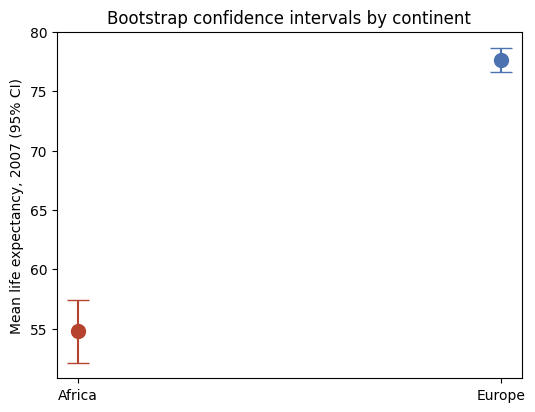

Africa: mean=54.81, 95% CI=[52.15, 57.44]
Europe: mean=77.65, 95% CI=[76.57, 78.65]


In [4]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    # TODO 1: resample `values` with replacement n_boot times, take the mean each time,
    # then return (overall mean, 2.5th percentile of boot means, 97.5th percentile)
    boot_means = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(n_boot)
    ])
    mean = values.mean()
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    return mean, ci_low, ci_high

# TODO 2: compute CIs for two continents of your choice
continent_a, continent_b = "Africa", "Europe"  # feel free to change these
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

# TODO 3: plot both as error bars (mean +/- CI half-width) on one chart
fig, ax = plt.subplots(figsize=(6, 4.5))
for i, (name, result, color) in enumerate([(continent_a, result_a, "#b5432e"),
                                            (continent_b, result_b, "#4C72B0")]):
    mean, lo, hi = result
    err = (hi - lo) / 2
    ax.errorbar(i, mean, yerr=err, fmt="o", color=color, capsize=8, markersize=10)
ax.set_xticks([0, 1])
ax.set_xticklabels([continent_a, continent_b])
ax.set_ylabel("Mean life expectancy, 2007 (95% CI)")
ax.set_title("Bootstrap confidence intervals by continent")
plt.show()

print(f"{continent_a}: mean={result_a[0]:.2f}, 95% CI=[{result_a[1]:.2f}, {result_a[2]:.2f}]")
print(f"{continent_b}: mean={result_b[0]:.2f}, 95% CI=[{result_b[1]:.2f}, {result_b[2]:.2f}]")


**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_ Africa has the wider interval: [52.15, 57.44] (width ≈ 5.3 years) versus
Europe's [76.57, 78.65] (width ≈ 2.1 years). Africa actually has *more* countries in the
dataset than Europe, so the wider interval isn't a smaller-n effect -- it's higher
variation (SD) among countries' life expectancies. African countries range enormously,
from countries in ongoing conflict or with severe health crises to comparatively stable,
higher-income nations, so the spread of `lifeExp` values is large. Europe's countries are
more uniformly high-income with strong healthcare systems, so their life expectancies
cluster tightly, giving a narrower bootstrap CI even off a similar or smaller sample.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

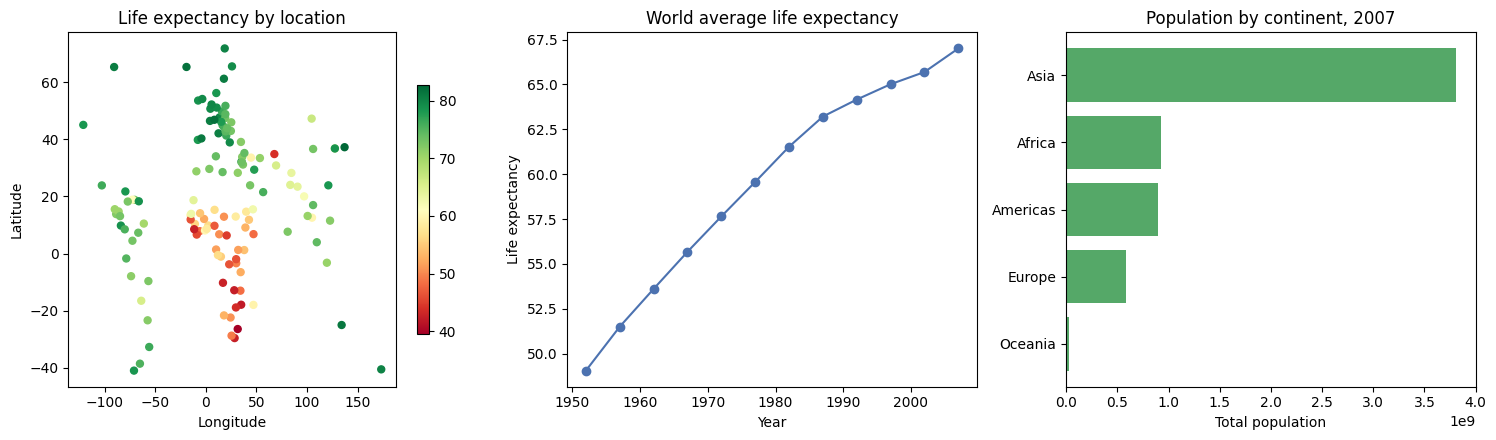

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter (axes[0])
sc = axes[0].scatter(gap_latest.centroid_lon, gap_latest.centroid_lat, c=gap_latest.lifeExp,
                      cmap="RdYlGn", s=25)
axes[0].set_title("Life expectancy by location")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
plt.colorbar(sc, ax=axes[0], shrink=0.7)

# TODO 2: world trend line (axes[1])
world_trend = gapminder.groupby("year")["lifeExp"].mean()
axes[1].plot(world_trend.index, world_trend.values, "o-", color="#4C72B0")
axes[1].set_title("World average life expectancy")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Life expectancy")

# TODO 3: population by continent bar chart (axes[2])
pop_by_continent = gap_latest.groupby("continent")["pop"].sum().sort_values()
axes[2].barh(pop_by_continent.index, pop_by_continent.values, color="#55A868")
axes[2].set_title("Population by continent, 2007")
axes[2].set_xlabel("Total population")

plt.tight_layout()
plt.show()


**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_ I'd keep the world-average life-expectancy trend line. A single map or bar
chart is a snapshot of "where things stand right now," but a director glancing every
morning is monitoring for *change* -- the trend line is the only one of the three panels
that directly answers "is the pattern we care about moving up, down, or flat over time,"
which is the core "trend" question from the lecture's monitoring framework. The map is
better for spotting spatial outliers and the bar chart for a single comparison, but
neither tells you whether things are getting better or worse at a glance.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_ I'd standardize on rate-based maps (GDP per capita, not
total GDP) for all future reports, because count-based choropleths are systematically
dominated by population size and produce a nearly entirely different "top 5" than the
rate view -- exactly the trap that misled the director on Greenland vs. India before.
When a journalist asks why the model predicted a specific number for one country, I'd
lead with local SHAP values rather than global feature importance: global importance can
only say "gdpPercap generally matters most across all countries," while local importance
gives the signed, in-years contribution of each feature for that one country, which is
what actually answers a "why THIS country" question. Finally, mean life expectancy by
continent -- and any other continent- or country-level average we report -- should never
be shown as a bare point estimate; as the bootstrap CIs showed, a continent's average can
carry a meaningfully wide range (Africa's is roughly 2.5x wider than Europe's), and
presenting it as a single fixed number would misrepresent how much uncertainty is
actually behind it.